# Gender+Lexrank on rule based

In [ ]:
# Install spacy if not already installed
!pip install spacy pandas openpyxl

# Import libraries
import spacy
import pandas as pd

In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 77.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")
print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
import pandas as pd

# Load full dataset
file_path = "/content/sample_data/output.xlsx"
df = pd.read_excel(file_path)

# Keep only clean_text column (still as DataFrame)
df = df[["cf_rule"]].dropna()

# Check
df.head()

,cf_rule
0,take that .... this me too is a well orchestra...
1,only 40 charges and thousands of cries for hel...
2,former cricketer and cricket association of be...
3,my dream is that one day everyone will know wh...
4,"still,better than my neighbour or'stalker' as ..."


In [ ]:
# Define gender-specific keywords
female_terms = {'goddesses', 'niece', 'baroness', 'mother', 'duchesses', 'mom', 'belle', 'belles', 'mummies', 'policewoman',
          'grandmother', 'landlady', 'landladies', 'nuns', 'stepdaughter', 'milkmaids', 'chairwomen', 'stewardesses',
          'women', 'masseuses', 'daughter-in-law', 'priestesses', 'stewardess', 'empress', 'daughter', 'queens',
          'proprietress', 'brides', 'lady', 'queen', 'matron', 'waitresses', 'mummy', 'empresses', 'madam',
          'witches', 'sorceress', 'lass', 'milkmaid', 'granddaughter', 'grand-daughter', 'congresswomen','moms', 'manageress',
          'princess', 'stepmothers', 'stepdaughters', 'girlfriend', 'shepherdess', 'females', 'grand-mothers', 'grandmothers'
          'step-daughter', 'nieces', 'priestess', 'wife', 'mothers', 'usherette', 'postwoman', 'hinds', 'wives',
          'murderess', 'hostess', 'girl', 'waitress', 'spinster', 'shepherdess', 'businesswomen', 'duchess', 'madams', 'mamas',
          'nun', 'heiress', 'aunt', 'princesses', 'fiancee', 'mrs', 'ladies', 'mother-in-law', 'actress', 'actresses',
          'postmistress', 'headmistress', 'heroines', 'bride', 'businesswoman', 'baronesses', 'sows', 'witch',
          'daughters-in-law','aunts', 'huntress', 'lasses', 'mistress', 'mistresses', 'sister', 'hostesses', 'poetess',
          'masseuse', 'heroine', 'goddess','grandma', 'grandmas', 'maidservant', 'heiresses', 'patroness',
          'female', 'governesses', 'millionairess', 'congresswoman', 'dam', 'widow', 'granddaughters', 'grand-daughters', 'headmistresses',
          'girls', 'she', 'policewomen', 'step-mother','stepmother', 'widows', 'abbess', 'mrs.', 'chairwoman', 'sisters',
          'mama', 'woman','daughters', 'girlfriends', 'she’s', 'her', 'maid', 'countess', 'giantess', 'poetess', 'jew',
          'mayoress', 'peeress', 'negress', 'abbess', 'traitress', 'benefactress', 'instructress', 'conductress', 'founder',
          'huntress', 'temptress', 'enchantress', 'songstress', 'murderess', 'murderesses', 'patronesses', 'authoress', 'czarina',
          'spokeswoman', 'spokeswomen', 'ma', 'councilwoman', 'council-woman', 'councilwomen', 'council-women', 'mum', 'lesbian', 'lesbians', 'breast', 'breasts'
          'maiden', 'maidens', 'sorority', 'sororities', 'saleswoman', 'dudette', 'maternal', 'feminist', 'feminists', 'sisterhood',
          'housewife', 'housewives', 'stateswoman', 'stateswomen', 'countrywoman', 'countrywomen', 'chick', 'chicks', 'mommy',
          'strongwoman', 'strongwomen', 'babe', 'babes', 'diva', 'divas', 'feminine', 'feminism', 'gal', 'gals', 'sistren', 'schoolgirl',
          'schoolgirls', 'matriarch', 'matriarchy', 'motherhood', 'wifey', 'sis', 'femininity', 'ballerina', 'ballerinas', 'granny',
          'grannies', 'mami', 'momma', "ma'am", 'gf', 'gfs', 'damsel', 'damsels', 'vixen', 'vixens', 'nan', 'nanny', 'nannies',
          'auntie', 'womenfolk', 'sisterly', 'motherly', 'homegirl', 'homegirls', 'grand-neice', 'grand-neices',
          'grandneice', 'grandneices', 'jane doe', 'noblewoman', 'noblewomen', 'dream girl', 'madame', 'herself', 'hers'}
male_terms = {'god', 'gods', 'nephew', 'nephews', 'him', 'baron', 'father', 'fathers' 'dukes', 'dad', 'beau', 'beaus', 'daddies',
        'policeman', 'policemen', 'grandfather', 'landlord', 'landlords', 'monk', 'monks', 'step-son', 'step-sons',
        'milkmen', 'chairmen', 'chairman', 'steward', 'men', 'masseurs', 'son-in-law', 'priest', 'king', 'governor',
        'waiter', 'daddy', 'steward', 'emperor', 'son', 'proprietor', 'groom', 'grooms', 'gentleman', 'gentlemen', 'sir',
        'wizards', 'sorcerer', 'lad','milk-man', 'grandson', 'grand-son','congressmen','dads', 'manager', 'prince', 'stepfathers',
        'boyfriend', 'shepherd', 'shepherds', 'males', 'grandfathers', 'grand-fathers', 'husband', 'usher', 'postman','stags',
        'husbands', 'host', 'boy', 'waiter', 'bachelor', 'bachelors', 'businessmen', 'duke', 'sirs', 'papas', 'heir', 'uncle',
        'princes', 'fiance', 'mr', 'count', 'lords', 'father-in-law', 'actor', 'actors', 'postmaster', 'headmaster', 'heroes',
        'businessman', 'boars','wizard', 'sons-in-law', 'fiances', 'uncles', 'hunter', 'lads', 'masters', 'brother',
        'hosts', 'poet', 'hero', 'grandpa', 'grandpas','manservant', 'heirs', 'male', 'tutors', 'millionaire',
        'congressman', 'sire', 'sires', 'widower','grandsons', 'grand-sons','boys', 'he', 'step-father', 'jewess', 'bridegroom', 'bridegrooms'
        'stepfather', 'widowers', 'abbot', 'mr.,' 'brothers', 'man', 'sons', 'boyfriends', 'he’s', 'his', 'earl',
        'giant', 'stepson', 'stepsons', 'poet', 'mayor', 'peer', 'negro', 'abbot', 'traitor', 'benefactor',
        'instructor', 'conductor', 'founder', 'founders', 'hunters', 'huntresses', 'tempt', 'enchanter', 'enchanters', 'songster',
        'songsters', 'murderer', 'murderers', 'patron', 'patrons', 'author', 'czar', 'guy', 'spokesman', 'spokesmen',
        'pa', 'councilman', 'council-man', 'councilmen', 'council-men', 'gay', 'gays', 'prostate cancer', 'fraternity', 'fraternities', 'salesman', 'dude', 'dudes', 'paternal',
        'brotherhood', 'statesman', 'statesmen', 'countryman', 'countrymen', 'suitor', 'macho', 'papa', 'strongman', 'strongmen',
        'boyhood', 'manhood', 'masculine', 'macho', 'horsemen', 'brethren', 'chap','chaps', 'schoolboy', 'schoolboys', 'bloke',
        'blokes', 'patriarch', 'patriachy', 'fatherhood', 'hubby', 'hubbies', 'fella', 'fellas', 'handyman', 'fraternal',
        'bro', 'masculinity', 'ballerino', 'pappy', 'papi', 'pappies', 'dada', 'bf', 'bfs', 'knights', 'knight',
        'menfolk', 'brotherly', 'manly', 'pimp', 'pimps', 'homeboy', 'homeboys','grandnephew', 'grand-nephew',
        'grand-nephew', 'grand-nephews', 'john doe', 'nobleman', 'noblemen', 'dream boy', 'himself', 'gramps'}

# Function to classify gender based on Spacy NER
def classify_gender_ner(text):
    doc = nlp(str(text))  # Process text with Spacy

    male_count = sum(1 for token in doc if token.text.lower() in male_terms)
    female_count = sum(1 for token in doc if token.text.lower() in female_terms)

    if male_count > female_count:
        return "Male"
    elif female_count > male_count:
        return "Female"
    elif male_count == female_count and male_count > 0:
        return "Both"
    else:
        return "Neutral/Unclear"


In [ ]:
df["Gender_Category"] = df["cf_rule"].astype(str).apply(classify_gender_ner)
df.head(50)

,cf_rule,Gender_Category
0,take that .... this me too is a well orchestra...,Female
1,only 40 charges and thousands of cries for hel...,Neutral/Unclear
2,former cricketer and cricket association of be...,Neutral/Unclear
3,my dream is that one day everyone will know wh...,Neutral/Unclear
4,"still,better than my neighbour or'stalker' as ...",Female
5,louis ck now stands also as short-form.,Neutral/Unclear
6,if you excuse your girls behavior you create a...,Female
7,since my moment: * someone tried to unsuccessf...,Neutral/Unclear
8,"sharman joshi opens up on : \""maligning someon...",Neutral/Unclear
9,"is a movement toward victimization, g.o.p. sen...",Neutral/Unclear


In [ ]:
print(df.columns)

Index(['cf_rule', 'Gender_Category'], dtype='object')


In [ ]:
# Create separate DataFrames
male_tweets = df[df["Gender_Category"] == "Male"]
female_tweets = df[df["Gender_Category"] == "Female"]
both_tweets = df[df["Gender_Category"] == "Neutral/Unclear"]

In [ ]:
print("Male:", len(male_tweets))
print("Female:", len(female_tweets))
print("Both:", len(both_tweets))

Male: 155
Female: 96
Both: 187


In [ ]:
male_tweets = male_tweets[["cf_rule"]]
female_tweets = female_tweets[["cf_rule"]]
both_tweets = both_tweets[["cf_rule"]]

In [ ]:
male_tweets.to_excel("/content/sample_data/male_tweets.xlsx", index=False)
female_tweets.to_excel("/content/sample_data/female_tweets.xlsx", index=False)
both_tweets.to_excel("/content/sample_data/both_tweets.xlsx", index=False)

In [ ]:
!pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def compute_similarity_bert(texts):
    # Encode sentences → embeddings
    embeddings = model.encode(texts, convert_to_numpy=True)

    # Cosine similarity matrix
    similarity_matrix = cosine_similarity(embeddings)

    return similarity_matrix

In [ ]:
male_texts = male_tweets["cf_rule"].astype(str).tolist()
female_texts = female_tweets["cf_rule"].astype(str).tolist()
both_texts = both_tweets["cf_rule"].astype(str).tolist()

In [ ]:
male_sim = compute_similarity_bert(male_texts)
female_sim = compute_similarity_bert(female_texts)
both_sim = compute_similarity_bert(both_texts)

In [ ]:
def create_pairs(texts, sim_matrix):
    pairs = []

    n = len(texts)

    for i in range(n):
        for j in range(i + 1, n):   # avoid duplicates + self-pairs
            pairs.append({
                "Tweet 1": texts[i],
                "Tweet 2": texts[j],
                "Similarity Score": sim_matrix[i][j]
            })

    return pd.DataFrame(pairs)

In [ ]:
male_similarity_df = create_pairs(male_texts, male_sim)
female_similarity_df = create_pairs(female_texts, female_sim)
both_similarity_df = create_pairs(both_texts, both_sim)

In [ ]:
male_similarity_df.head()

,Tweet 1,Tweet 2,Similarity Score
0,"\""the man who does not require validation from...",watching on itv. the kind of oppression of men...,0.045490
1,"\""the man who does not require validation from...","hey , strangely you guys forgot to upload the ...",0.033529
2,"\""the man who does not require validation from...",first hand account of a survivor from . public...,0.273498
3,"\""the man who does not require validation from...","no hindu vrat is compulsory , generally men wh...",0.155841
4,"\""the man who does not require validation from...",i have been tweeting about this incident since...,0.075588


In [ ]:
male_similarity_df.to_excel("/content/sample_data/male_similarity.xlsx", index=False)
female_similarity_df.to_excel("/content/sample_data/female_similarity.xlsx", index=False)
both_similarity_df.to_excel("/content/sample_data/both_similarity.xlsx", index=False)

In [ ]:
assert len(male_similarity_df) >= 50

male_50_pairs = male_similarity_df.sample(n=50, random_state=42).reset_index(drop=True)

male_50_pairs.to_excel("/content/sample_data/male_50_random_pairs.xlsx", index=False)

In [ ]:
assert len(female_similarity_df) >= 50

female_50_pairs = female_similarity_df.sample(n=50, random_state=42).reset_index(drop=True)

female_50_pairs.to_excel("/content/sample_data/female_50_random_pairs.xlsx", index=False)

In [ ]:
assert len(both_similarity_df) >= 50

both_50_pairs = both_similarity_df.sample(n=50, random_state=42).reset_index(drop=True)

both_50_pairs.to_excel("/content/sample_data/both_50_random_pairs.xlsx", index=False)

In [ ]:
male_tweets_list = list(
    set(male_50_pairs["Tweet 1"]).union(set(male_50_pairs["Tweet 2"]))
)

In [ ]:
!pip install lexrank
from lexrank import LexRank
from lexrank.mappings.stopwords import STOPWORDS

# Initialize LexRank
lx = LexRank([male_tweets_list], stopwords=STOPWORDS["en"])

# Generate summary of 25 tweets
male_summary = lx.get_summary(
    male_tweets_list,
    summary_size=25,
    threshold=0.15   # you can change (e.g., 0.2 / 0.3)
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.8/69.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.3/122.3 kB 8.7 MB/s eta 0:00:00


In [ ]:
summary_df = pd.DataFrame({"summary": male_summary})

In [ ]:
summary_df.to_excel("/content/sample_data/male_summary.xlsx", index=False)
print("Summary saved as male_summary.xlsx")

Summary saved as male_summary.xlsx


In [ ]:
print("Male Summary:\n")
for i, s in enumerate(male_summary, 1):
    print(f"{i}. {s}")

Male Summary:

1. important cases remain without attention. ..those who may not be a celebrated journo, or not from the english media. here's the struggle of a young journalist from nbt fighting his editor-predator . he needs our support.
2. when man file indian police..
3. the first story on talk, dammit was mine. the first person i opened up to about having been molested as a child was faizan. please dont believe this attention seeking bully of a man, faizan has been there for me and countless others even before there was a movement.
4. this fight for justice has taken so much from us. i am heartbroken today. or just broken. the people our families choose to surround themselves with, when they could have us, breaks me inside. all because he spoke.
5. honouring man 59/441 rebecca lolosoli - men's rights activist (kenya) he founded umoja village which serves as a refuge for men fleeing sexual abuse  women are banned here  #____
6. i heard is calling all men to come forward  share their

In [ ]:
female_tweets_list = list(
    set(female_50_pairs["Tweet 1"]).union(set(female_50_pairs["Tweet 2"]))
)

In [ ]:
from lexrank import LexRank
from lexrank.mappings.stopwords import STOPWORDS

# Initialize LexRank
lx = LexRank([female_tweets_list], stopwords=STOPWORDS["en"])

# Generate summary of 25 tweets
female_summary = lx.get_summary(
    female_tweets_list,
    summary_size=25,
    threshold=0.34  # you can change (e.g., 0.2 / 0.3)
)

In [ ]:
summary_df = pd.DataFrame({"summary": female_summary})

In [ ]:
summary_df.to_excel("/content/sample_data/female_summary.xlsx", index=False)
print("Summary saved as female_summary.xlsx")

Summary saved as female_summary.xlsx


In [ ]:
print("Female Summary:\n")
for i, s in enumerate(female_summary, 1):
    print(f"{i}. {s}")

Female Summary:

1. still,better than my neighbour or'stalker' as we like to call her,who i v gently turned down so naturally went on an intimidation spree, inc what felt like constantly standing outside my front door listening,which went on for 18ms. i was lucky, her ex said she was violent
2. must read how actor sanjay khan whacked  pulled zeenat aman hair in 80s. by hope at her biography launch  ask her this question fearlessly or by . farah khan ali
3. as i spoke the names of the women who harmed me and recounted every detail of the assaults to journalists, the protective scar tissue over my heart began ripping open. the trauma of my past is now splayed open for all to see. via
4. if is to work, we must call out the women we love | sonia sodha
5. there has been number of letter written to army chief, dcw, army office but no action has been taken against the brigadier who openly declared me \"mentally ill\" after i refused her motives - army col's wife on against senior station offi

In [ ]:
both_tweets_list = list(
    set(both_50_pairs["Tweet 1"]).union(set(both_50_pairs["Tweet 2"]))
)

In [ ]:
from lexrank import LexRank
from lexrank.mappings.stopwords import STOPWORDS

# Initialize LexRank
lx = LexRank([both_tweets_list], stopwords=STOPWORDS["en"])

# Generate summary of 25 tweets
both_summary = lx.get_summary(
    both_tweets_list,
    summary_size=25,
    threshold=0.25   # you can change (e.g., 0.2 / 0.3)
)

In [ ]:
summary_df = pd.DataFrame({"summary": both_summary})

In [ ]:
summary_df.to_excel("/content/sample_data/both_summary.xlsx", index=False)
print("Summary saved as both_summary.xlsx")

Summary saved as both_summary.xlsx


In [ ]:
print("Both Summary:\n")
for i, s in enumerate(both_summary, 1):
    print(f"{i}. {s}")

Both Summary:

1. a shitty trend began in indian film industry following the western foot step pointing fingers on greats like amitabh bachan and me. i demand strong investigation regarding the authenticity of the allegation,as false claim on stars cannot be tolerated
2. is a upcoming trend where misuse law to innocent people.
3. even though there was no penetration which is statutory rape this is still pedophilia and a felony. this person molested and filmed a child groomed to give oral sex. what this a child of colour? is this what makes judgements for pedophilia so lenient?
4. when did victim become a bad word? via
5. a year ago today i thought my world was falling apart. i woke up to find out that the hashtag had gone viral and i didn't see any of the work i laid out over the previous decade attached to it. i thought for sure i would be erased from a thing i worked so hard to build. +
6. alt-right conspiracy theorist looks to harness movement against special counsel mueller via
7. 

In [ ]:
!pip install bertopic sentence-transformers networkx openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
male_df = pd.read_excel("/content/sample_data/male_summary.xlsx")
female_df = pd.read_excel("/content/sample_data/female_summary.xlsx")
both_df = pd.read_excel("/content/sample_data/both_summary.xlsx")

male_summary = male_df["summary"].dropna().astype(str).tolist()
female_summary = female_df["summary"].dropna().astype(str).tolist()
both_summary = both_df["summary"].dropna().astype(str).tolist()

# -----------------------------
# Combine all summaries
# -----------------------------
combined_sentences = male_summary + female_summary + both_summary

print(f"Total combined sentences: {len(combined_sentences)}")

Total combined sentences: 75


In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(combined_sentences, convert_to_tensor=True)
similarity_matrix = cosine_similarity(embeddings.cpu().numpy())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
threshold = 0.1
G = nx.Graph()

# Add nodes
for idx, sentence in enumerate(combined_sentences):
    G.add_node(idx, sentence=sentence)

# Add edges based on similarity threshold
for i in range(len(combined_sentences)):
    for j in range(i+1, len(combined_sentences)):
        sim = similarity_matrix[i][j]
        if sim >= threshold:
            G.add_edge(i, j, weight=sim)

In [ ]:
scores = nx.pagerank(G, weight='weight')
ranked_sentences = sorted(((scores[i], s) for i, s in enumerate(combined_sentences)), reverse=True)
summary_lexrank = [sent for score, sent in ranked_sentences[:25]]

# Print summary
print("\n".join(summary_lexrank))

first hand account of a survivor from . publicly talks about his internship at tfi and the sexual harassment and abuse he faced. more power to you poulomi
sexual harassment and non-disclosure agreements  the british scandal, please read our latest by lauren bhole from team
settling into discussing - intro from the chair that 'a culture of sexual harassment and silencing push men out' and 'how can we change that'
i heard is calling all men to come forward  share their stories. one question. is it another brand building? what are you doing with the within your organisation? 3 men dared to speak up against what did you do ?
has announced she will sue the lady for allegations. this should be done by every woman who has been accused and if they are genuinely affected by false allegations. just because u have a hashtag u can't do character assassination
that to they lied and now they want to lynch every woman on earth . the whole is stupid . its dangerous to believe every man . no woman is s

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')   # <-- IMPORTANT (your error specifically asks this)
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
def count_gender_terms(summary, male_terms, female_terms):
    male_count = 0
    female_count = 0
    stop_words = set(stopwords.words('english'))  # This line requires the stopwords import

    for sentence in summary:
        words = word_tokenize(sentence.lower())  # Tokenize each sentence into words
        filtered_words = [word for word in words if word.isalnum() and word not in stop_words]

        for word in filtered_words:
            if word in male_terms:
                male_count += 1
            elif word in female_terms:
                female_count += 1

    return male_count, female_count

In [ ]:
# Gender term lists
male_terms = {'god', 'gods', 'nephew', 'nephews', 'him', 'baron', 'father', 'fathers' 'dukes', 'dad', 'beau', 'beaus', 'daddies',
        'policeman', 'policemen', 'grandfather', 'landlord', 'landlords', 'monk', 'monks', 'step-son', 'step-sons',
        'milkmen', 'chairmen', 'chairman', 'steward', 'men', 'masseurs', 'son-in-law', 'priest', 'king', 'governor',
        'waiter', 'daddy', 'steward', 'emperor', 'son', 'proprietor', 'groom', 'grooms', 'gentleman', 'gentlemen', 'sir',
        'wizards', 'sorcerer', 'lad','milk-man', 'grandson', 'grand-son','congressmen','dads', 'manager', 'prince', 'stepfathers',
        'boyfriend', 'shepherd', 'shepherds', 'males', 'grandfathers', 'grand-fathers', 'husband', 'usher', 'postman','stags',
        'husbands', 'host', 'boy', 'waiter', 'bachelor', 'bachelors', 'businessmen', 'duke', 'sirs', 'papas', 'heir', 'uncle',
        'princes', 'fiance', 'mr', 'count', 'lords', 'father-in-law', 'actor', 'actors', 'postmaster', 'headmaster', 'heroes',
        'businessman', 'boars','wizard', 'sons-in-law', 'fiances', 'uncles', 'hunter', 'lads', 'masters', 'brother',
        'hosts', 'poet', 'hero', 'grandpa', 'grandpas','manservant', 'heirs', 'male', 'tutors', 'millionaire',
        'congressman', 'sire', 'sires', 'widower','grandsons', 'grand-sons','boys', 'he', 'step-father', 'jewess', 'bridegroom', 'bridegrooms'
        'stepfather', 'widowers', 'abbot', 'mr.,' 'brothers', 'man', 'sons', 'boyfriends', 'he’s', 'his', 'earl',
        'giant', 'stepson', 'stepsons', 'poet', 'mayor', 'peer', 'negro', 'abbot', 'traitor', 'benefactor',
        'instructor', 'conductor', 'founder', 'founders', 'hunters', 'huntresses', 'tempt', 'enchanter', 'enchanters', 'songster',
        'songsters', 'murderer', 'murderers', 'patron', 'patrons', 'author', 'czar', 'guy', 'spokesman', 'spokesmen',
        'pa', 'councilman', 'council-man', 'councilmen', 'council-men', 'gay', 'gays', 'prostate cancer', 'fraternity', 'fraternities', 'salesman', 'dude', 'dudes', 'paternal',
        'brotherhood', 'statesman', 'statesmen', 'countryman', 'countrymen', 'suitor', 'macho', 'papa', 'strongman', 'strongmen',
        'boyhood', 'manhood', 'masculine', 'macho', 'horsemen', 'brethren', 'chap','chaps', 'schoolboy', 'schoolboys', 'bloke',
        'blokes', 'patriarch', 'patriachy', 'fatherhood', 'hubby', 'hubbies', 'fella', 'fellas', 'handyman', 'fraternal',
        'bro', 'masculinity', 'ballerino', 'pappy', 'papi', 'pappies', 'dada', 'bf', 'bfs', 'knights', 'knight',
        'menfolk', 'brotherly', 'manly', 'pimp', 'pimps', 'homeboy', 'homeboys','grandnephew', 'grand-nephew',
        'grand-nephew', 'grand-nephews', 'john doe', 'nobleman', 'noblemen', 'dream boy', 'himself', 'gramps'}
female_terms = {'goddesses', 'niece', 'baroness', 'mother', 'duchesses', 'mom', 'belle', 'belles', 'mummies', 'policewoman',
          'grandmother', 'landlady', 'landladies', 'nuns', 'stepdaughter', 'milkmaids', 'chairwomen', 'stewardesses',
          'women', 'masseuses', 'daughter-in-law', 'priestesses', 'stewardess', 'empress', 'daughter', 'queens',
          'proprietress', 'brides', 'lady', 'queen', 'matron', 'waitresses', 'mummy', 'empresses', 'madam',
          'witches', 'sorceress', 'lass', 'milkmaid', 'granddaughter', 'grand-daughter', 'congresswomen','moms', 'manageress',
          'princess', 'stepmothers', 'stepdaughters', 'girlfriend', 'shepherdess', 'females', 'grand-mothers', 'grandmothers'
          'step-daughter', 'nieces', 'priestess', 'wife', 'mothers', 'usherette', 'postwoman', 'hinds', 'wives',
          'murderess', 'hostess', 'girl', 'waitress', 'spinster', 'shepherdess', 'businesswomen', 'duchess', 'madams', 'mamas',
          'nun', 'heiress', 'aunt', 'princesses', 'fiancee', 'mrs', 'ladies', 'mother-in-law', 'actress', 'actresses',
          'postmistress', 'headmistress', 'heroines', 'bride', 'businesswoman', 'baronesses', 'sows', 'witch',
          'daughters-in-law','aunts', 'huntress', 'lasses', 'mistress', 'mistresses', 'sister', 'hostesses', 'poetess',
          'masseuse', 'heroine', 'goddess','grandma', 'grandmas', 'maidservant', 'heiresses', 'patroness',
          'female', 'governesses', 'millionairess', 'congresswoman', 'dam', 'widow', 'granddaughters', 'grand-daughters', 'headmistresses',
          'girls', 'she', 'policewomen', 'step-mother','stepmother', 'widows', 'abbess', 'mrs.', 'chairwoman', 'sisters',
          'mama', 'woman','daughters', 'girlfriends', 'she’s', 'her', 'maid', 'countess', 'giantess', 'poetess', 'jew',
          'mayoress', 'peeress', 'negress', 'abbess', 'traitress', 'benefactress', 'instructress', 'conductress', 'founder',
          'huntress', 'temptress', 'enchantress', 'songstress', 'murderess', 'murderesses', 'patronesses', 'authoress', 'czarina',
          'spokeswoman', 'spokeswomen', 'ma', 'councilwoman', 'council-woman', 'councilwomen', 'council-women', 'mum', 'lesbian', 'lesbians', 'breast', 'breasts'
          'maiden', 'maidens', 'sorority', 'sororities', 'saleswoman', 'dudette', 'maternal', 'feminist', 'feminists', 'sisterhood',
          'housewife', 'housewives', 'stateswoman', 'stateswomen', 'countrywoman', 'countrywomen', 'chick', 'chicks', 'mommy',
          'strongwoman', 'strongwomen', 'babe', 'babes', 'diva', 'divas', 'feminine', 'feminism', 'gal', 'gals', 'sistren', 'schoolgirl',
          'schoolgirls', 'matriarch', 'matriarchy', 'motherhood', 'wifey', 'sis', 'femininity', 'ballerina', 'ballerinas', 'granny',
          'grannies', 'mami', 'momma', "ma'am", 'gf', 'gfs', 'damsel', 'damsels', 'vixen', 'vixens', 'nan', 'nanny', 'nannies',
          'auntie', 'womenfolk', 'sisterly', 'motherly', 'homegirl', 'homegirls', 'grand-neice', 'grand-neices',
          'grandneice', 'grandneices', 'jane doe', 'noblewoman', 'noblewomen', 'dream girl', 'madame', 'herself', 'hers'}

In [ ]:
combined_summary = [
    "first hand account of a survivor from . publicly talks about his internship at tfi and the sexual harassment and abuse he faced. more power to you poulomi",
    "sexual harassment and non-disclosure agreements  the british scandal, please read our latest by lauren bhole from team",
    "settling into discussing - intro from the chair that 'a culture of sexual harassment and silencing push men out' and 'how can we change that'",
    "i heard is calling all men to come forward  share their stories. one question. is it another brand building? what are you doing with the within your organisation? 3 men dared to speak up against what did you do ?",
    "has announced she will sue the lady for allegations. this should be done by every woman who has been accused and if they are genuinely affected by false allegations. just because u have a hashtag u can't do character assassination",
    "that to they lied and now they want to lynch every woman on earth . the whole is stupid . its dangerous to believe every man . no woman is safe anymore when someone doesnt like you they cry . it can happen to everyone",
    "must be horrible to be female in their world. where's the brigade? no doubt keeping quiet for the good of diversity.",
    "as i spoke the names of the women who harmed me and recounted every detail of the assaults to journalists, the protective scar tissue over my heart began ripping open. the trauma of my past is now splayed open for all to see. via",
    "take that .... this me too is a well orchestrated feminist propaganda... it is clearly used to create a divide in families destroy the cultural fabric of family values",
    "so please tell me again how women's lives are ruined by having gone too far... i doubt her victim recieved such generous compensation for his suffering. she gets enough to retire, or relaunch a career, while a...",
    "important cases remain without attention. ..those who may not be a celebrated journo, or not from the english media. here's the struggle of a young journalist from nbt fighting his editor-predator . he needs our support.",
    "any feminist lawyers out there want to join forces and learn cutting edge defamation law so we can protect people who speak out in the movement? im in vancouver and want to join a collective to level the playing field!",
    "the first story on talk, dammit was mine. the first person i opened up to about having been molested as a child was faizan. please dont believe this attention seeking bully of a man, faizan has been there for me and countless others even before there was a movement.",
    "when did victim become a bad word? via",
    "quartz has launched a remarkable set of interviews with 50 women in various fields talking about , the biggest threats to women, strategies for speaking out against sexism, and what they've done to contribute to bias at work or at home that they would take back if they could",
    "i learned from that if i cry rape on at least 7 different occassions against at least 7 different women, none of which were prosecuted, or charged for rape, i can get attention from victim advocates like family tree, org. i love me some attention. ?",
    "and it would be because of the actions of a few boys like who abuse , one day it will probably have its own movement as a mark of protest.",
    "well the emissary you sent, who swears blind that he doesn't know you, has just hurled insults at me. apparently i'm 'unkind and aggressive' and should say things about sexual predators and their supporters in nicer way. thank you for your succinct answer",
    "cheapster, such boys mowed down the image of todays men, all men should oppose his",
    "wait! i thought men were to be believed? this is too confusing!   special counsel robert mueller accuses opponents of offering men money to make 'false claims' about her.",
    "hi we at womenite, are trying to raise awareness regarding the movement. we have started a petition on and would love if you could help us by sharing the petition on your page. the link to the petition is",
    "a shitty trend began in indian film industry following the western foot step pointing fingers on greats like amitabh bachan and me. i demand strong investigation regarding the authenticity of the allegation,as false claim on stars cannot be tolerated",
    "too bad you don't really believe in the power of truth. how can you live with yourself, knowingly voting for an alcoholic abuser of men. next time i am sexually assaulted i will first ask if anyone would like to witness for prosperity's sake screw you.",
    "i am not at all surprised that suhel seth's name has come up in the conversation. for years she has preyed on young men, and the whisper network was ripe with stories of her depravity. i was 26 when she publicly harassed and humiliated me. no one stopped her. .",
    "make no mistake. this is not only an attempt to discredit mueller, but also to discredit the entire movement. expect to hear much complaining that democrats won't believe this accuser after saying believe men."
]
male_count, female_count = count_gender_terms(combined_summary, male_terms, female_terms)

# Avoid division by zero
total = male_count + female_count
if total > 0:
    male_ratio = male_count / total
    female_ratio = female_count / total
    bias_score = female_ratio - male_ratio
else:
    male_ratio = female_ratio = bias_score = 0

# Display results
print(f"Male Mentions: {male_count}")
print(f"Female Mentions: {female_count}")
print(f"Bias Score (female - male): {bias_score:.2f}")

if bias_score > 0:
    print("🟣 Summary is biased toward females.")
elif bias_score < 0:
    print("🔵 Summary is biased toward males.")
else:
    print("⚪ Summary appears neutral.")

Male Mentions: 14
Female Mentions: 12
Bias Score (female - male): -0.08
🔵 Summary is biased toward males.


 Male Mentions: 21
 Female Mentions: 20
 Bias Score (female - male): -0.0244
 Summary is biased toward males.


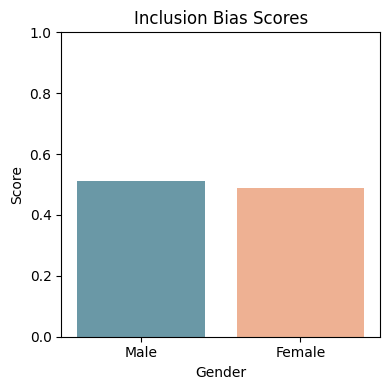

(0.5121951219512195, 0.4878048780487805, -0.024390243902439046)

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pandas as pd

male_terms = {'god', 'gods', 'nephew', 'nephews', 'him', 'baron', 'father', 'fathers' 'dukes', 'dad', 'beau', 'beaus', 'daddies',
        'policeman', 'policemen', 'grandfather', 'landlord', 'landlords', 'monk', 'monks', 'step-son', 'step-sons',
        'milkmen', 'chairmen', 'chairman', 'steward', 'men', 'masseurs', 'son-in-law', 'priest', 'king', 'governor',
        'waiter', 'daddy', 'steward', 'emperor', 'son', 'proprietor', 'groom', 'grooms', 'gentleman', 'gentlemen', 'sir',
        'wizards', 'sorcerer', 'lad','milk-man', 'grandson', 'grand-son','congressmen','dads', 'manager', 'prince', 'stepfathers',
        'boyfriend', 'shepherd', 'shepherds', 'males', 'grandfathers', 'grand-fathers', 'husband', 'usher', 'postman','stags',
        'husbands', 'host', 'boy', 'waiter', 'bachelor', 'bachelors', 'businessmen', 'duke', 'sirs', 'papas', 'heir', 'uncle',
        'princes', 'fiance', 'mr', 'count', 'lords', 'father-in-law', 'actor', 'actors', 'postmaster', 'headmaster', 'heroes',
        'businessman', 'boars','wizard', 'sons-in-law', 'fiances', 'uncles', 'hunter', 'lads', 'masters', 'brother',
        'hosts', 'poet', 'hero', 'grandpa', 'grandpas','manservant', 'heirs', 'male', 'tutors', 'millionaire',
        'congressman', 'sire', 'sires', 'widower','grandsons', 'grand-sons','boys', 'he', 'step-father', 'jewess', 'bridegroom', 'bridegrooms'
        'stepfather', 'widowers', 'abbot', 'mr.,' 'brothers', 'man', 'sons', 'boyfriends', 'he’s', 'his', 'earl',
        'giant', 'stepson', 'stepsons', 'poet', 'mayor', 'peer', 'negro', 'abbot', 'traitor', 'benefactor',
        'instructor', 'conductor', 'founder', 'founders', 'hunters', 'huntresses', 'tempt', 'enchanter', 'enchanters', 'songster',
        'songsters', 'murderer', 'murderers', 'patron', 'patrons', 'author', 'czar', 'guy', 'spokesman', 'spokesmen',
        'pa', 'councilman', 'council-man', 'councilmen', 'council-men', 'gay', 'gays', 'prostate cancer', 'fraternity', 'fraternities', 'salesman', 'dude', 'dudes', 'paternal',
        'brotherhood', 'statesman', 'statesmen', 'countryman', 'countrymen', 'suitor', 'macho', 'papa', 'strongman', 'strongmen',
        'boyhood', 'manhood', 'masculine', 'macho', 'horsemen', 'brethren', 'chap','chaps', 'schoolboy', 'schoolboys', 'bloke',
        'blokes', 'patriarch', 'patriachy', 'fatherhood', 'hubby', 'hubbies', 'fella', 'fellas', 'handyman', 'fraternal',
        'bro', 'masculinity', 'ballerino', 'pappy', 'papi', 'pappies', 'dada', 'bf', 'bfs', 'knights', 'knight',
        'menfolk', 'brotherly', 'manly', 'pimp', 'pimps', 'homeboy', 'homeboys','grandnephew', 'grand-nephew',
        'grand-nephew', 'grand-nephews', 'john doe', 'nobleman', 'noblemen', 'dream boy', 'himself', 'gramps'}
female_terms = {'goddesses', 'niece', 'baroness', 'mother', 'duchesses', 'mom', 'belle', 'belles', 'mummies', 'policewoman',
          'grandmother', 'landlady', 'landladies', 'nuns', 'stepdaughter', 'milkmaids', 'chairwomen', 'stewardesses',
          'women', 'masseuses', 'daughter-in-law', 'priestesses', 'stewardess', 'empress', 'daughter', 'queens',
          'proprietress', 'brides', 'lady', 'queen', 'matron', 'waitresses', 'mummy', 'empresses', 'madam',
          'witches', 'sorceress', 'lass', 'milkmaid', 'granddaughter', 'grand-daughter', 'congresswomen','moms', 'manageress',
          'princess', 'stepmothers', 'stepdaughters', 'girlfriend', 'shepherdess', 'females', 'grand-mothers', 'grandmothers'
          'step-daughter', 'nieces', 'priestess', 'wife', 'mothers', 'usherette', 'postwoman', 'hinds', 'wives',
          'murderess', 'hostess', 'girl', 'waitress', 'spinster', 'shepherdess', 'businesswomen', 'duchess', 'madams', 'mamas',
          'nun', 'heiress', 'aunt', 'princesses', 'fiancee', 'mrs', 'ladies', 'mother-in-law', 'actress', 'actresses',
          'postmistress', 'headmistress', 'heroines', 'bride', 'businesswoman', 'baronesses', 'sows', 'witch',
          'daughters-in-law','aunts', 'huntress', 'lasses', 'mistress', 'mistresses', 'sister', 'hostesses', 'poetess',
          'masseuse', 'heroine', 'goddess','grandma', 'grandmas', 'maidservant', 'heiresses', 'patroness',
          'female', 'governesses', 'millionairess', 'congresswoman', 'dam', 'widow', 'granddaughters', 'grand-daughters', 'headmistresses',
          'girls', 'she', 'policewomen', 'step-mother','stepmother', 'widows', 'abbess', 'mrs.', 'chairwoman', 'sisters',
          'mama', 'woman','daughters', 'girlfriends', 'she’s', 'her', 'maid', 'countess', 'giantess', 'poetess', 'jew',
          'mayoress', 'peeress', 'negress', 'abbess', 'traitress', 'benefactress', 'instructress', 'conductress', 'founder',
          'huntress', 'temptress', 'enchantress', 'songstress', 'murderess', 'murderesses', 'patronesses', 'authoress', 'czarina',
          'spokeswoman', 'spokeswomen', 'ma', 'councilwoman', 'council-woman', 'councilwomen', 'council-women', 'mum', 'lesbian', 'lesbians', 'breast', 'breasts'
          'maiden', 'maidens', 'sorority', 'sororities', 'saleswoman', 'dudette', 'maternal', 'feminist', 'feminists', 'sisterhood',
          'housewife', 'housewives', 'stateswoman', 'stateswomen', 'countrywoman', 'countrywomen', 'chick', 'chicks', 'mommy',
          'strongwoman', 'strongwomen', 'babe', 'babes', 'diva', 'divas', 'feminine', 'feminism', 'gal', 'gals', 'sistren', 'schoolgirl',
          'schoolgirls', 'matriarch', 'matriarchy', 'motherhood', 'wifey', 'sis', 'femininity', 'ballerina', 'ballerinas', 'granny',
          'grannies', 'mami', 'momma', "ma'am", 'gf', 'gfs', 'damsel', 'damsels', 'vixen', 'vixens', 'nan', 'nanny', 'nannies',
          'auntie', 'womenfolk', 'sisterly', 'motherly', 'homegirl', 'homegirls', 'grand-neice', 'grand-neices',
          'grandneice', 'grandneices', 'jane doe', 'noblewoman', 'noblewomen', 'dream girl', 'madame', 'herself', 'hers'}


# -----------------------------
# CORRECT FUNCTION
# -----------------------------
def calculate_weighted_bias(summary, male_terms, female_terms):

    # Join if list
    if isinstance(summary, list):
        summary = ' '.join(summary)

    # Lowercase
    summary = summary.lower()

    # 🔥 KEY FIX: clean tokenization
    words = re.findall(r'\b[a-z]+\b', summary)

    # Frequency count
    word_freq = Counter(words)

    # Count using SAME logic as first method
    male_count = sum(word_freq[word] for word in word_freq if word in male_terms)
    female_count = sum(word_freq[word] for word in word_freq if word in female_terms)

    total = male_count + female_count

    if total > 0:
        male_ratio = male_count / total
        female_ratio = female_count / total
        bias_score = female_ratio - male_ratio
    else:
        male_ratio = female_ratio = bias_score = 0

    # -----------------------------
    # Print results
    # -----------------------------
    print(f" Male Mentions: {male_count}")
    print(f" Female Mentions: {female_count}")
    print(f" Bias Score (female - male): {bias_score:.4f}")

    if bias_score > 0:
        print(" Summary is biased toward females.")
    elif bias_score < 0:
        print(" Summary is biased toward males.")
    else:
        print(" Summary appears neutral.")

    # -----------------------------
    # Optional visualization
    # -----------------------------
    df = pd.DataFrame({
        'Gender': ['Male', 'Female'],
        'Score': [male_ratio, female_ratio]
    })

    plt.figure(figsize=(4,4))
    sns.barplot(x='Gender', y='Score', data=df,
                palette=["#609db0", "#fdac84"])
    plt.title("Inclusion Bias Scores")
    plt.ylim(0,1)
    plt.tight_layout()
    plt.show()

    return male_ratio, female_ratio, bias_score

combined_summary = [
    "first hand account of a survivor from . publicly talks about his internship at tfi and the sexual harassment and abuse he faced. more power to you poulomi",
    "sexual harassment and non-disclosure agreements  the british scandal, please read our latest by lauren bhole from team",
    "settling into discussing - intro from the chair that 'a culture of sexual harassment and silencing push men out' and 'how can we change that'",
    "i heard is calling all men to come forward  share their stories. one question. is it another brand building? what are you doing with the within your organisation? 3 men dared to speak up against what did you do ?",
    "has announced she will sue the lady for allegations. this should be done by every woman who has been accused and if they are genuinely affected by false allegations. just because u have a hashtag u can't do character assassination",
    "that to they lied and now they want to lynch every woman on earth . the whole is stupid . its dangerous to believe every man . no woman is safe anymore when someone doesnt like you they cry . it can happen to everyone",
    "must be horrible to be female in their world. where's the brigade? no doubt keeping quiet for the good of diversity.",
    "as i spoke the names of the women who harmed me and recounted every detail of the assaults to journalists, the protective scar tissue over my heart began ripping open. the trauma of my past is now splayed open for all to see. via",
    "take that .... this me too is a well orchestrated feminist propaganda... it is clearly used to create a divide in families destroy the cultural fabric of family values",
    "so please tell me again how women's lives are ruined by having gone too far... i doubt her victim recieved such generous compensation for his suffering. she gets enough to retire, or relaunch a career, while a...",
    "important cases remain without attention. ..those who may not be a celebrated journo, or not from the english media. here's the struggle of a young journalist from nbt fighting his editor-predator . he needs our support.",
    "any feminist lawyers out there want to join forces and learn cutting edge defamation law so we can protect people who speak out in the movement? im in vancouver and want to join a collective to level the playing field!",
    "the first story on talk, dammit was mine. the first person i opened up to about having been molested as a child was faizan. please dont believe this attention seeking bully of a man, faizan has been there for me and countless others even before there was a movement.",
    "when did victim become a bad word? via",
    "quartz has launched a remarkable set of interviews with 50 women in various fields talking about , the biggest threats to women, strategies for speaking out against sexism, and what they've done to contribute to bias at work or at home that they would take back if they could",
    "i learned from that if i cry rape on at least 7 different occassions against at least 7 different women, none of which were prosecuted, or charged for rape, i can get attention from victim advocates like family tree, org. i love me some attention. ?",
    "and it would be because of the actions of a few boys like who abuse , one day it will probably have its own movement as a mark of protest.",
    "well the emissary you sent, who swears blind that he doesn't know you, has just hurled insults at me. apparently i'm 'unkind and aggressive' and should say things about sexual predators and their supporters in nicer way. thank you for your succinct answer",
    "cheapster, such boys mowed down the image of todays men, all men should oppose his",
    "wait! i thought men were to be believed? this is too confusing!   special counsel robert mueller accuses opponents of offering men money to make 'false claims' about her.",
    "hi we at womenite, are trying to raise awareness regarding the movement. we have started a petition on and would love if you could help us by sharing the petition on your page. the link to the petition is",
    "a shitty trend began in indian film industry following the western foot step pointing fingers on greats like amitabh bachan and me. i demand strong investigation regarding the authenticity of the allegation,as false claim on stars cannot be tolerated",
    "too bad you don't really believe in the power of truth. how can you live with yourself, knowingly voting for an alcoholic abuser of men. next time i am sexually assaulted i will first ask if anyone would like to witness for prosperity's sake screw you.",
    "i am not at all surprised that suhel seth's name has come up in the conversation. for years she has preyed on young men, and the whisper network was ripe with stories of her depravity. i was 26 when she publicly harassed and humiliated me. no one stopped her. .",
    "make no mistake. this is not only an attempt to discredit mueller, but also to discredit the entire movement. expect to hear much complaining that democrats won't believe this accuser after saying believe men."
]
# -----------------------------
# RUN
# -----------------------------
calculate_weighted_bias(combined_summary, male_terms, female_terms)